**BN5212 Advanced Machine learning for Biomedical Engineering and Sciences [Assignment 2]**

In this assignment, you will embark on a deep learning journey of medical image analysis by completing the following tasks:


Task 1. Medical Image Classification from chest x-ray images(**12 points**)

Task 2. Medical Image Abnormality Detection from chest x-ray images (**13 points**)

Implementation Guidelines
- Implement your codes **within the "TODO" sections** according to the **corresponding bold questions**.
- Keep your code **clean, readable, and well-organized**.
- Ensure that your code is **fully runnable** without errors.

Output & Experimental Results
- Save **all required experimental results** **in this notebook**.
- **Grading will be based on the outputs and results** recorded in the notebook.

Submission Details
- **Submission Path**: Canvas → `Assignments` → `Assignment 2`
- **Deadline**: **19 October 2026, 23:59 (SGT)**
- **Individual Project**: Do NOT share your solutions with others. Zero tolerance for plagiarism and cheating.
- **Late submissions** will receive the following maximum marks:
   * 0–1 hour late: 90%
   * 1–12 hours late: 80%
   * 12–24 hours late: 60%
   * 24–48 hours late: 40%
   * 48–72 hours late: 20%
   * More than 72 hours late: 0%

Resource Limits
- Google Colab provides **free GPU resources** for about **3–12 hours per day**.
- It is recommended to **schedule your experiments and coding sessions properly**.

If you have any questions regarding this project, please contact:  
- **Teaching Assistant**: Meng Linghao → [e1583364@u.nus.edu](mailto:e1583364@u.nus.edu)  
- **Teaching Assistant**: Mohammad Nuwaisir Rahman → [nuwaisir@u.nus.edu](mailto:nuwaisir@u.nus.edu)  
- **Assistant Professor**: Jin Yueming → [ymjin@nus.edu.sg](mailto:ymjin@nus.edu.sg)

Assessment Emphasis for This Assignment
- The **25 points** are distributed as follows: **Core code implementation: 13 points; Optimization research experiment: 12 points.**
- Completing the provided `TODO` code is required for a runnable submission, but a substantial portion of the marks is awarded for experimental reasoning rather than boilerplate implementation.

**Submitting via Canvas system**

Kindly submit **2 files** of your answers separately to "Assignments --> Assignment 2" on Canvas, including one original .ipynb file and one converted pdf file.



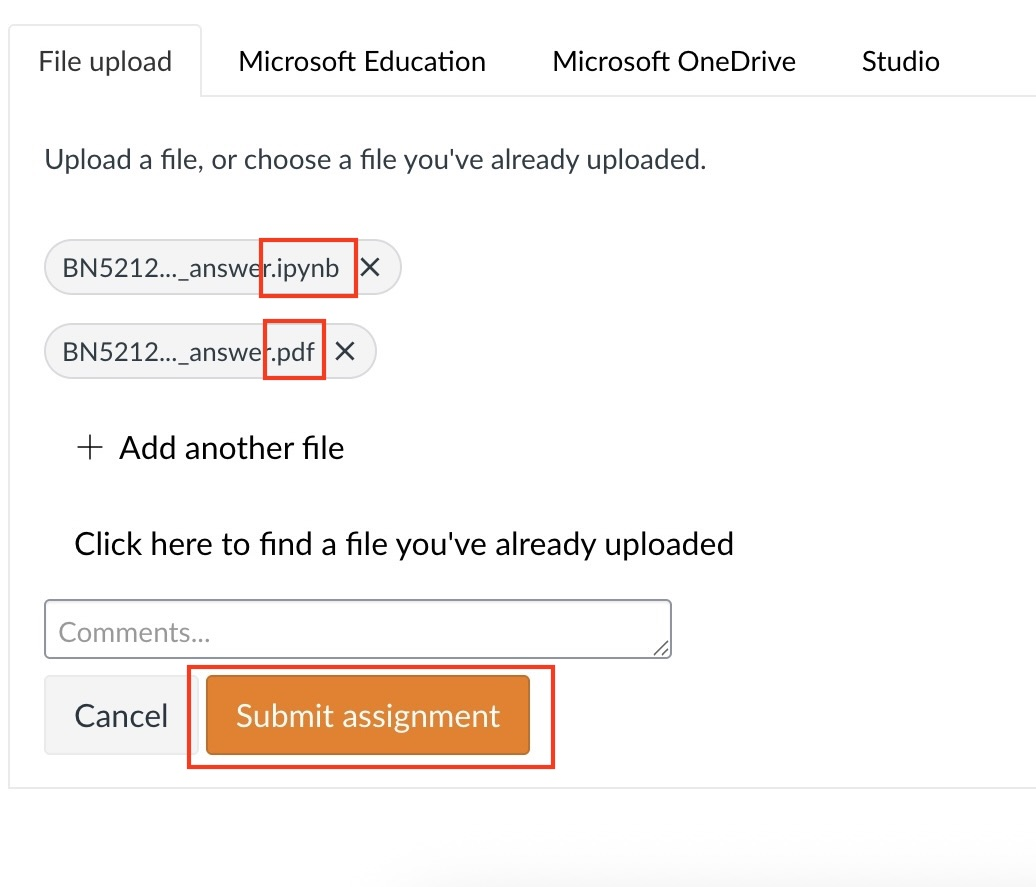


How to convert .ipynb file to pdf file:

**Make sure your converted pdf file contains all the code pages and your results, missing results will be regarded as Unfinished during grading.**

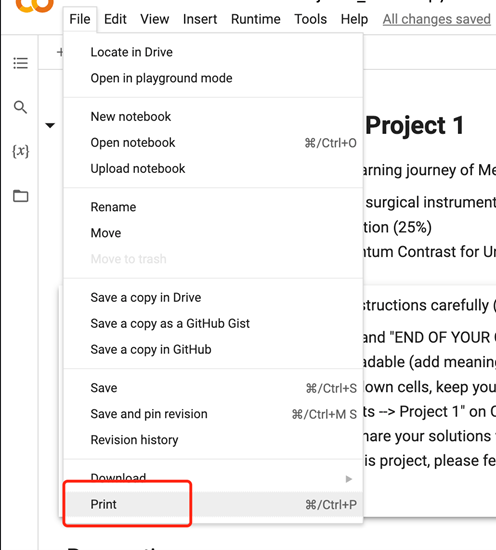

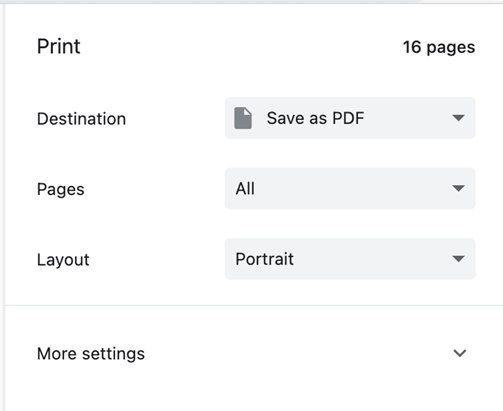

## Task 1: Medical Image Classification (Chest X-ray Classification)

**Description:**

You are tasked with implementing and training a **vision transformer** model from scratch to classify medical images (e.g., Chest X-rays for pneumonia classification).

**Requirements:**

1. Build a Vision Transformer model using the provided code framework.

2. Use a medical image dataset (e.g., Chest X-ray).

3. Improve model performance by experimenting with different techniques, such as:

- Data augmentation (rotation, flipping, etc.).

- Fine-tuning hyperparameters (e.g., learning rate, batch size).

4. Report the accuracy and provide reasoning for model refinement choices.

**Deliverables:**

Completed code with a model achieving a good accuracy improvement.

Brief report detailing the strategies you used to improve the model’s performance.

**Assessment for Task 1 (12 points):** Core implementation **6 points**; Optimization research experiment **6 points**.



**Step1**:

Please download the dataset from https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia to implement a classification task of Pneumonia over Chest X-ray images.

After finishing downloading the .zip file, upload and unzip it.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def set_seed(seed=42):
    """Fix random seeds so every model starts from identical weights."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128 | CUDA available: True


In [1]:
import os
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Flatten,
    Reshape,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    BatchNormalization,
    LayerNormalization,
    Activation,
    Add,
    Concatenate
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
print(os.listdir("/kaggle/input"))
# Find the chest_xray directory automatically

DATA_PATH = None

for root, dirs, files in os.walk("/kaggle/input"):
    if "train" in dirs and "test" in dirs:
        DATA_PATH = root
        break

if DATA_PATH is None:
    raise FileNotFoundError("Could not find chest_xray dataset.")

print("Dataset path:", DATA_PATH)
print("Contents:", os.listdir(DATA_PATH))

['datasets']
Dataset path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Contents: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [4]:

TRAIN_PATH = os.path.join(DATA_PATH, "train")
VAL_PATH   = os.path.join(DATA_PATH, "val")
TEST_PATH  = os.path.join(DATA_PATH, "test")

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)

print("\nTrain classes:", os.listdir(TRAIN_PATH))

Train: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Validation: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
Test: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test

Train classes: ['PNEUMONIA', 'NORMAL']


**Step 2**:

**Please complete the following section by building a multi-head self-attention mechanism from scratch (1.5 points).**

In [5]:
def Your_attention(Q, K, V, num_head):
    # Q, K, V: [B, N, D]

    B, N, D = Q.shape

    assert D % num_head == 0, \
        "Embedding dimension must be divisible by number of heads"

    head_dim = D // num_head

    # [B, N, D] -> [B, num_head, N, head_dim]
    Q = Q.reshape(B, N, num_head, head_dim).transpose(1, 2)
    K = K.reshape(B, N, num_head, head_dim).transpose(1, 2)
    V = V.reshape(B, N, num_head, head_dim).transpose(1, 2)

    # Scaled dot-product attention
    scores = torch.matmul(Q, K.transpose(-2, -1))
    scores = scores / (head_dim ** 0.5)

    attention_weights = torch.softmax(scores, dim=-1)

    # Apply attention to V
    out = torch.matmul(attention_weights, V)

    # Combine heads:
    # [B, num_head, N, head_dim] -> [B, N, D]
    out = out.transpose(1, 2).contiguous()
    out = out.reshape(B, N, D)

    return out

**Please complete the following section by building a patch embedding module and transformer encoder layers (1.5 points).**

To make the code shorter and easier to read, we remove the positional embedding part in this part.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.image_size = image_size

        # Number of image patches
        self.num_patches = (image_size // patch_size) ** 2

        # Split image into patches and project them into embed_dim
        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)

        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()

        self.num_heads = num_heads
        self.embed_dim = embed_dim

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):

        B, N, D = x.size()

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        out = self.out(
            Your_attention(Q, K, V, self.num_heads)
        )

        return out

class TransformerEncoderLayer(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        feedforward_dim,
        dropout=0.1
    ):
        super(TransformerEncoderLayer, self).__init__()

        self.attn = MultiHeadSelfAttention(
            embed_dim,
            num_heads
        )

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, feedforward_dim),
            nn.ReLU(),
            nn.Linear(feedforward_dim, embed_dim)
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # Multi-head attention
        attn_out = self.attn(x)

        # Residual connection + normalization
        x = self.norm1(
            x + self.dropout(attn_out)
        )

        # Feed-forward network
        ffn_out = self.ffn(x)

        # Residual connection + normalization
        x = self.norm2(
            x + self.dropout(ffn_out)
        )

        return x

class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim, num_heads, num_layers, num_classes, feedforward_dim=2048, dropout=0.1):
        super(VisionTransformer, self).__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)

        # [TODO] defining the CLS token in the following.
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)
        )

        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(embed_dim, num_heads, feedforward_dim, dropout)
            for _ in range(num_layers)
        ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):

        # Convert image into patch embeddings
        x = self.patch_embedding(x)

        B = x.shape[0]

        # Expand CLS token for entire batch
        cls_tokens = self.cls_token.expand(
            B, -1, -1
        )

        # Add CLS token before patch embeddings
        x = torch.cat(
            (cls_tokens, x),
            dim=1
        )

        # Transformer encoder layers
        for encoder_layer in self.encoder_layers:
            x = encoder_layer(x)

        # Extract CLS token
        cls_output = x[:, 0]

        # Classification head
        x = self.mlp_head(cls_output)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer(224, 16, 3, 384, 8, 8, 2, 1024)
model = model.to(device)

input_tensor = torch.randn(4, 3, 224, 224).cuda()
output = model(input_tensor)
print(output.shape)

torch.Size([4, 2])


**Step 3**:

The following codes give a template about how to construct your own dataset from scratch with using torch.dataset class. **Please fill in the template (1 point).**

In [7]:
# ============================================================
# CHEST X-RAY DATASET
# ============================================================

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class ChestXRayDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = []
        self.labels = []

        # ----------------------------------------------------
        # Load image paths and labels
        # NORMAL = 0
        # PNEUMONIA = 1
        # ----------------------------------------------------

        class_names = ["NORMAL", "PNEUMONIA"]

        for label, class_name in enumerate(class_names):

            class_dir = os.path.join(root_dir, class_name)

            for filename in os.listdir(class_dir):

                # Only include image files
                if filename.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                ):
                    image_path = os.path.join(
                        class_dir,
                        filename
                    )

                    self.image_paths.append(image_path)
                    self.labels.append(label)


    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, idx):

        # Get image path
        image_path = self.image_paths[idx]

        # Get corresponding label
        label = self.labels[idx]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to PyTorch tensor
        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label


# ============================================================
# IMAGE TRANSFORMATIONS
# ============================================================

data_transforms = transforms.Compose([

    # Resize for ViT
    transforms.Resize((224, 224)),

    # Ensure image has 3 channels
    transforms.Grayscale(num_output_channels=3),

    # PIL Image -> PyTorch Tensor
    transforms.ToTensor(),
])


# ============================================================
# KAGGLE DATASET PATHS
# ============================================================

train_dir = os.path.join(DATA_PATH, "train")
test_dir  = os.path.join(DATA_PATH, "test")

print("Train directory:", train_dir)
print("Test directory :", test_dir)


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = ChestXRayDataset(
    root_dir=train_dir,
    transform=data_transforms
)

test_dataset = ChestXRayDataset(
    root_dir=test_dir,
    transform=data_transforms
)


# ============================================================
# CREATE DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)


# ============================================================
# CHECK NUMBER OF IMAGES
# ============================================================

print("\nTrain NORMAL samples:",
      len([label for label in train_dataset.labels if label == 0]))

print("Train PNEUMONIA samples:",
      len([label for label in train_dataset.labels if label == 1]))

print("Test NORMAL samples:",
      len([label for label in test_dataset.labels if label == 0]))

print("Test PNEUMONIA samples:",
      len([label for label in test_dataset.labels if label == 1]))

Train directory: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Test directory : /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test

Train NORMAL samples: 1341
Train PNEUMONIA samples: 3875
Test NORMAL samples: 234
Test PNEUMONIA samples: 390


**Step 4**:

This is a basic training function. **Please incorporate learning rate decay strategy to enhance the training process and analyze its effect (1 point).**

Epoch 1/15: 100%|██████████| 326/326 [01:09<00:00,  4.66it/s, loss=0.684]


Epoch 1: avg loss = 0.7247, lr = 1.00e-04


Epoch 2/15: 100%|██████████| 326/326 [00:50<00:00,  6.52it/s, loss=0.54] 


Epoch 2: avg loss = 0.6195, lr = 9.89e-05


Epoch 3/15: 100%|██████████| 326/326 [00:51<00:00,  6.37it/s, loss=0.606]


...

Epoch 13: avg loss = 0.2536, lr = 1.05e-05


Epoch 14/15: 100%|██████████| 326/326 [00:50<00:00,  6.48it/s, loss=0.294] 


Epoch 14: avg loss = 0.2354, lr = 5.28e-06


Epoch 15/15: 100%|██████████| 326/326 [00:51<00:00,  6.38it/s, loss=0.127] 


Epoch 15: avg loss = 0.2231, lr = 2.08e-06
LR per epoch: ['1.00e-04', '9.89e-05', '9.57e-05', '9.05e-05', '8.36e-05', '7.52e-05', '6.58e-05', '5.57e-05', '4.53e-05', '3.52e-05', '2.58e-05', '1.74e-05', '1.05e-05', '5.28e-06', '2.08e-06']


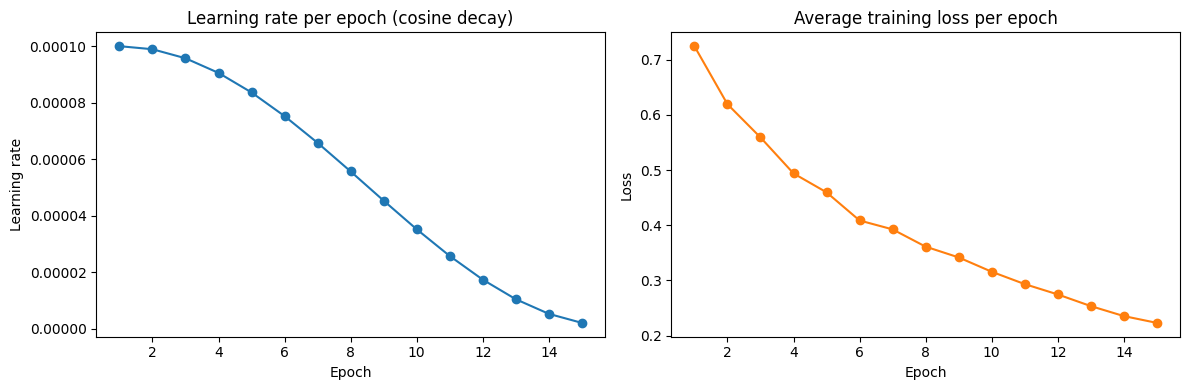

In [8]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 0.4], device=device)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 15

# Learning-rate decay: cosine annealing.
# The LR starts at 1e-4 and decreases smoothly to 1e-6 by the final epoch:
# large steps early for fast progress, small steps later for fine convergence.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def train_model(model, criterion, optimizer, scheduler, loader, num_epochs=NUM_EPOCHS):
    lr_list, loss_list = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

        for inputs, labels in progress_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        lr_list.append(optimizer.param_groups[0]["lr"])   # LR used during this epoch
        loss_list.append(running_loss / len(loader))
        print(f"Epoch {epoch + 1}: avg loss = {loss_list[-1]:.4f}, lr = {lr_list[-1]:.2e}")

        scheduler.step()   # decay the LR for the next epoch

    print("LR per epoch:", [f"{lr:.2e}" for lr in lr_list])
    return model, lr_list, loss_list


model, lr_list, loss_list = train_model(model, criterion, optimizer, scheduler, train_loader)
torch.save(model.state_dict(), "chest_xray_vit.pth")

# Plot the LR schedule and training loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, NUM_EPOCHS + 1), lr_list, marker="o")
ax[0].set_title("Learning rate per epoch (cosine decay)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Learning rate")
ax[1].plot(range(1, NUM_EPOCHS + 1), loss_list, marker="o", color="tab:orange")
ax[1].set_title("Average training loss per epoch")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss")
plt.tight_layout()
plt.show()

In [ ]:
print(baseline_train_metrics)

**Step 5**:

Evaluating your method. **Please calculate the following metrics and print them: accuracy, precision, recall, and kappa value. In addition, please plot the ROC curve and confusion matrix. (1 point)**

The following links can help you understand these metrics better.

https://www.analyticsvidhya.com/blog/2021/07/metrics-to-evaluate-your-classification-model-to-take-the-right-decisions/

https://en.wikipedia.org/wiki/Cohen%27s_kappa

https://docs.kolena.com/metrics/cohens-kappa/

https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc


In [ ]:
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, cohen_kappa_score, roc_curve, auc)


def test_model(model, loader, title="", plot=True):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Required metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)

    # Extra: specificity and error counts (used in Step 6)
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    # ROC curve and AUC
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    print(f"--- {title} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Cohen Kappa: {kappa:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print(f"False positives (NORMAL -> PNEUMONIA): {fp}, False negatives: {fn}")

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["NORMAL", "PNEUMONIA"],
                    yticklabels=["NORMAL", "PNEUMONIA"], ax=ax[0])
        ax[0].set_title(f"Confusion Matrix {title}")
        ax[0].set_ylabel("True Label")
        ax[0].set_xlabel("Predicted Label")

        ax[1].plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
        ax[1].plot([0, 1], [0, 1], linestyle="--", label="Random guess")
        ax[1].set_title(f"ROC Curve {title}")
        ax[1].set_xlabel("False Positive Rate")
        ax[1].set_ylabel("True Positive Rate")
        ax[1].legend(loc="lower right")

        plt.tight_layout()
        plt.show()

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall,
            "Specificity": specificity, "Kappa": kappa, "AUC": roc_auc,
            "FP": int(fp), "FN": int(fn)}


model.load_state_dict(torch.load("chest_xray_vit.pth"))
baseline_metrics = test_model(model, test_loader, title="(Baseline, test set)")

# Training-set evaluation (no augmentation, no shuffling), used in Step 6
train_eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
baseline_train_metrics = test_model(model, train_eval_loader, title="(Baseline, train set)", plot=False)

**Step 6: Optimization Research Experiment (6 points)**

Using the final ViT from Steps 1–5 as the baseline, with its selected hyperparameters fixed, identify **one meaningful improvement opportunity**, analyze its possible cause, and design an experiment to address it.

**Important:** Use the best hyperparameter settings obtained from Steps 1–5 and keep them fixed throughout this experiment. Hyperparameter tuning itself should not be considered an intervention.

1. **Baseline diagnosis (1 point)**: Identify a specific issue in the baseline results and propose a possible cause.

2. **Experiment design (1 point)**: Propose one intervention based on the cause. Change **one** main factor at a time while keeping the other important settings controlled.

3. **Experiment (2 points)**: Implement the proposed experiment in code, run all the experiment including evaluation, and also save all required outputs and results in the notebook.

4. **Analysis and Interpretation (2 points)**: Compare the modified model with the baseline using relevant evaluation metrics, and determine whether the intervention copes with the identified issue

**Possible interventions** include, but are **not limited to**, modifying the loss function, class-imbalance handling (e.g., class-balanced sampling), data augmentation, representation aggregation (e.g., mean pooling instead of CLS-token pooling), or model architecture improvement.

**Example:**
1. **Baseline diagnosis**: The Baseline model achieves high recall but relatively low precision because many normal images are misclassified as pneumonia. One possible cause is that the current loss does not sufficiently focus on hard-to-classify normal samples.
3. **Experiment design**: The experiment could replace weighted cross-entropy with Focal Loss while keeping all other settings unchanged.
4. **Experiment**: ...... (Experiment code and results)
5. **Analysis and Interpretation**: Precision Score with the modified model is..., while that of baseline is..., which indicates...

**Yours:**
1. **Baseline diagnosis**:

The baseline ViT (weighted cross-entropy, Adam, cosine LR decay, 15 epochs, no augmentation) is
strongly biased towards predicting PNEUMONIA , with a Recall of 0.923 (30 of 390 pneumonia cases missed),
Specificity of 0.624 (88 of 234 normal X-rays flagged as pneumonia) 

The main weakness is recognising NORMAL X-rays: 38% of healthy patients are misclassified, which
lowers precision and Kappa and would cause many unnecessary follow-ups in practice.

Possible cause: overfitting and poor generalisation. The model reaches 0,9accuracy on
the training set but 0.811 on the test set. A Vision Transformer trained from scratch has weak
built-in assumptions about images (unlike a CNN) and typically needs very large datasets; with only
about 5,200 training images, it can memorise scan-specific details such as exact positioning,
brightness and contrast instead of learning features of the disease. The NORMAL class is the minority
(1,341 vs 3,875 images), so its features are learned from the least data and are the first to fail on
unseen test images, which then default to the majority PNEUMONIA class.

2. **Experiment design(data augmentation)**:

Applied random data augmentation to the training images only. Each time a training
image is loaded, it receives a small random transformation that keeps its label unchanged:
- `RandomAffine`: rotation up to ±10°, translation up to 5%, scaling between 0.9 and 1.1, simulating
  differences in patient positioning;
- `ColorJitter`: brightness and contrast changes of up to ±20%, simulating differences between scanners
  and exposure settings.

Horizontal flipping is deliberately excluded, because it would place the heart on the wrong side of
the chest, which never occurs in real X-rays.

This could address the cause as the model sees a different random version of each image in
every epoch, it cannot memorise exact scans or rely on shortcuts such as overall brightness or
position. It is pushed to learn features that remain consistent under these variations, such as the
texture of lung opacities, which should generalise better to unseen patients.

Controlled setup: everything else is identical to the baseline: the same ViT architecture and size,
weighted cross-entropy loss ([1.0, 0.4]), Adam with LR 1e-4, cosine LR decay, 15 epochs, batch size 16,
and the same unaugmented test set and evaluation code. The only changed factor is the training-data
augmentation.

Hypothesis: if overfitting causes the misclassified NORMAL images, augmentation should increase
specificity and precision and reduce the train-test gap, ideally without a large drop in recall.

3. **Experiment**:

In [25]:
import random

def set_seed(seed=42):
    random.seed(seed
               
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

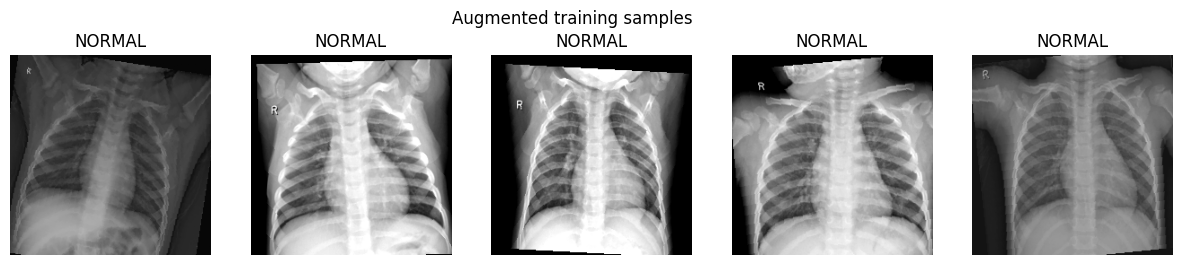

Epoch 1/15: 100%|██████████| 326/326 [00:55<00:00,  5.84it/s, loss=0.733]


Epoch 1: avg loss = 0.7333, lr = 1.00e-04


Epoch 2/15: 100%|██████████| 326/326 [00:54<00:00,  5.95it/s, loss=0.703]


Epoch 2: avg loss = 0.6982, lr = 9.89e-05


Epoch 3/15: 100%|██████████| 326/326 [00:55<00:00,  5.91it/s, loss=0.713]


...

Epoch 13: avg loss = 0.4173, lr = 1.05e-05


Epoch 14/15: 100%|██████████| 326/326 [00:58<00:00,  5.61it/s, loss=0.34] 


Epoch 14: avg loss = 0.3840, lr = 5.28e-06


Epoch 15/15: 100%|██████████| 326/326 [00:57<00:00,  5.69it/s, loss=0.178]

Epoch 15: avg loss = 0.3673, lr = 2.08e-06
LR per epoch: ['1.00e-04', '9.89e-05', '9.57e-05', '9.05e-05', '8.36e-05', '7.52e-05', '6.58e-05', '5.57e-05', '4.53e-05', '3.52e-05', '2.58e-05', '1.74e-05', '1.05e-05', '5.28e-06', '2.08e-06']


In [26]:

# EXPERIMENT: training-set data augmentation

aug_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

train_dataset_aug = ChestXRayDataset(root_dir=train_dir, transform=aug_transforms)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=16, shuffle=True, num_workers=2)

# Show a few augmented samples as a sanity check
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img, label = train_dataset_aug[i * 300]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title("NORMAL" if label == 0 else "PNEUMONIA")
    ax.axis("off")
plt.suptitle("Augmented training samples")
plt.show()

# Identical model, loss, optimiser, scheduler and epochs as the baseline
set_seed(42)
model_aug = VisionTransformer(224, 16, 3, 384, 8, 8, 2, 1024).to(device)
criterion_aug = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 0.4], device=device)).to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-4)
scheduler_aug = optim.lr_scheduler.CosineAnnealingLR(optimizer_aug, T_max=NUM_EPOCHS, eta_min=1e-6)

model_aug, lr_list_aug, loss_list_aug = train_model(
    model_aug, criterion_aug, optimizer_aug, scheduler_aug, train_loader_aug
)
torch.save(model_aug.state_dict(), "chest_xray_vit_aug.pth")

4. **Analysis and Interpretation**:

--- (Augmented, test set) ---
Accuracy: 0.7981
Precision: 0.8455
Recall: 0.8282
Specificity: 0.7479
Cohen Kappa: 0.5722
AUC: 0.8906
False positives (NORMAL -> PNEUMONIA): 59, False negatives: 67


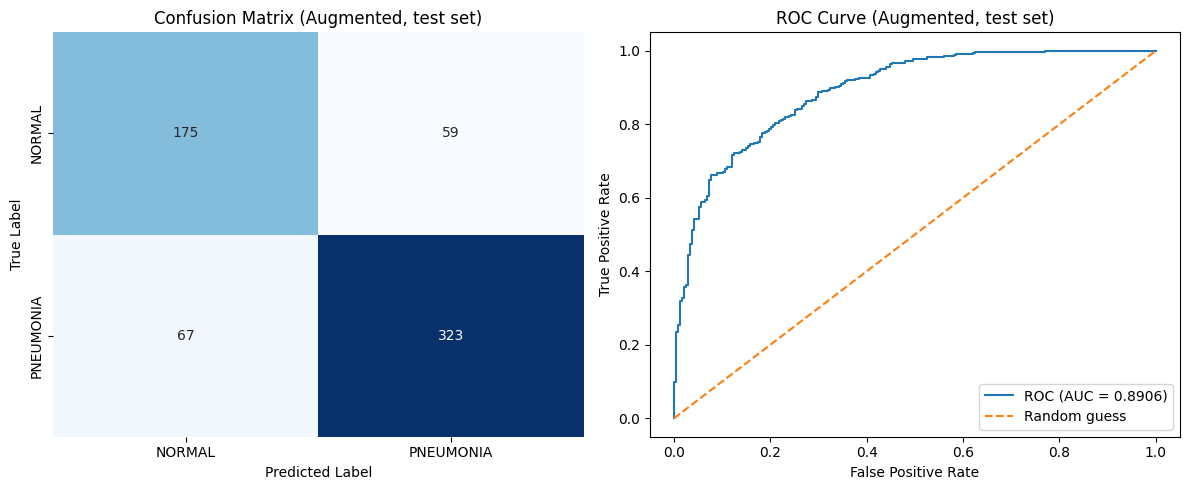

--- (Augmented, train set) ---
Accuracy: 0.8439
Precision: 0.9500
Recall: 0.8338
Specificity: 0.8732
Cohen Kappa: 0.6338
AUC: 0.9241
False positives (NORMAL -> PNEUMONIA): 170, False negatives: 644

Test-set comparison:


,Accuracy,Precision,Recall,Specificity,Kappa,AUC,FP,FN
Baseline,0.8109,0.8036,0.9231,0.6239,0.5755,0.8723,88.0,30.0
Augmented,0.7981,0.8455,0.8282,0.7479,0.5722,0.8906,59.0,67.0
Change,-0.0128,0.0420,-0.0949,0.1239,-0.0034,0.0183,-29.0,37.0



Train vs test accuracy gap:


,Train accuracy,Test accuracy,Gap
Baseline,0.9080,0.8109,0.0971
Augmented,0.8439,0.7981,0.0459


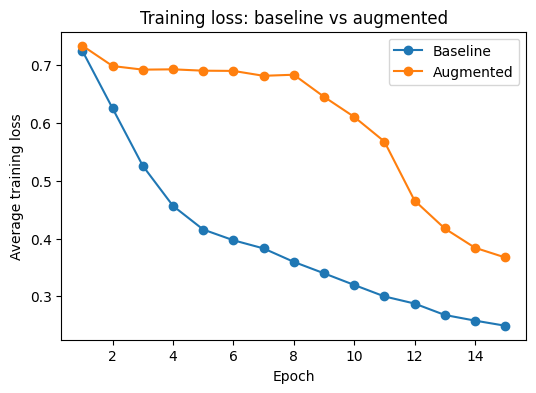

In [27]:
# ============================================================
# Evaluate the augmented model with the same code and test set
# ============================================================
aug_metrics = test_model(model_aug, test_loader, title="(Augmented, test set)")
aug_train_metrics = test_model(model_aug, train_eval_loader, title="(Augmented, train set)", plot=False)

# Side-by-side comparison on the test set
comparison = pd.DataFrame({"Baseline": baseline_metrics, "Augmented": aug_metrics}).T
comparison.loc["Change"] = comparison.loc["Augmented"] - comparison.loc["Baseline"]
print("\nTest-set comparison:")
display(comparison.round(4))

# Train vs test gap (a measure of overfitting)
gap = pd.DataFrame({
    "Train accuracy": [baseline_train_metrics["Accuracy"], aug_train_metrics["Accuracy"]],
    "Test accuracy": [baseline_metrics["Accuracy"], aug_metrics["Accuracy"]],
}, index=["Baseline", "Augmented"])
gap["Gap"] = gap["Train accuracy"] - gap["Test accuracy"]
print("\nTrain vs test accuracy gap:")
display(gap.round(4))

# Training loss curves
plt.figure(figsize=(6, 4))
plt.plot(range(1, NUM_EPOCHS + 1), loss_list, marker="o", label="Baseline")
plt.plot(range(1, NUM_EPOCHS + 1), loss_list_aug, marker="o", label="Augmented")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("Training loss: baseline vs augmented")
plt.legend()
plt.show()

In [28]:
# ============================================================
# EXPERIMENT 2: augmentation + learnable positional embeddings
# Only change vs the augmented model: positional embeddings.
# ============================================================

class VisionTransformerPos(VisionTransformer):
    def __init__(self, image_size, patch_size, in_channels, embed_dim, num_heads,
                 num_layers, num_classes, feedforward_dim=2048, dropout=0.1):
        # Build the exact same ViT as before (same seed -> same starting weights)
        super().__init__(image_size, patch_size, in_channels, embed_dim, num_heads,
                         num_layers, num_classes, feedforward_dim, dropout)

        # NEW: one learnable 384-number vector per position (196 patches + 1 CLS)
        num_tokens = self.patch_embedding.num_patches + 1
        self.pos_embed = nn.Parameter(torch.zeros(1, num_tokens, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)   # standard ViT initialisation

    def forward(self, x):
        x = self.patch_embedding(x)                       # [B, 196, D]
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)     # [B, 1, D]
        x = torch.cat((cls_tokens, x), dim=1)             # [B, 197, D]

        x = x + self.pos_embed                            # NEW: add position information

        for encoder_layer in self.encoder_layers:
            x = encoder_layer(x)

        cls_output = x[:, 0]
        return self.mlp_head(cls_output)


# Identical settings to the augmented model
set_seed(42)
model_pos = VisionTransformerPos(224, 16, 3, 384, 8, 8, 2, 1024).to(device)
criterion_pos = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 0.4], device=device)).to(device)
optimizer_pos = optim.Adam(model_pos.parameters(), lr=1e-4)
scheduler_pos = optim.lr_scheduler.CosineAnnealingLR(optimizer_pos, T_max=NUM_EPOCHS, eta_min=1e-6)

model_pos, lr_list_pos, loss_list_pos = train_model(
    model_pos, criterion_pos, optimizer_pos, scheduler_pos, train_loader_aug   # same augmented data
)
torch.save(model_pos.state_dict(), "chest_xray_vit_aug_pos.pth")

Epoch 1/15: 100%|██████████| 326/326 [00:55<00:00,  5.88it/s, loss=0.698]


Epoch 1: avg loss = 0.7325, lr = 1.00e-04


Epoch 2/15: 100%|██████████| 326/326 [00:55<00:00,  5.92it/s, loss=0.703]


Epoch 2: avg loss = 0.7016, lr = 9.89e-05


Epoch 3/15: 100%|██████████| 326/326 [00:55<00:00,  5.87it/s, loss=0.665]


...

Epoch 13: avg loss = 0.5257, lr = 1.05e-05


Epoch 14/15: 100%|██████████| 326/326 [00:54<00:00,  5.97it/s, loss=0.495]


Epoch 14: avg loss = 0.4409, lr = 5.28e-06


Epoch 15/15: 100%|██████████| 326/326 [00:54<00:00,  5.98it/s, loss=0.413]


Epoch 15: avg loss = 0.4126, lr = 2.08e-06
LR per epoch: ['1.00e-04', '9.89e-05', '9.57e-05', '9.05e-05', '8.36e-05', '7.52e-05', '6.58e-05', '5.57e-05', '4.53e-05', '3.52e-05', '2.58e-05', '1.74e-05', '1.05e-05', '5.28e-06', '2.08e-06']


Augmentation addressed the original issue: specificity rose from 0.624 to 0.748 and false positives
fell by a third. However, recall dropped from 0.923 to 0.828, and missed pneumonia cases more than
doubled. Kappa and accuracy were essentially unchanged, so at the default 0.5 threshold the model
traded one kind of error for another rather than reducing total errors.

The remaining issue is that the model's overall ability to separate the two classes is still limited:
AUC improved only to 0.891. A better representation, not just a different balance of errors, is needed
to improve both recall and specificity together.

Possible cause: the model has no positional embeddings, which were removed from the template. Self-
attention on its own treats the 196 patches as an unordered set, so the model cannot tell which part
of the chest a patch comes from: left or right lung, upper or lower zone, lung tissue or image border.
In chest X-rays, location is clinically meaningful. Pneumonia typically appears as opacity within
specific lung regions, while bright areas near the edges or over the heart and spine are normal
anatomy. Without position information, a hazy patch over the heart and a hazy patch in the lower lung
look identical to the model, which limits how well it can separate NORMAL from PNEUMONIA.

Deeper models or different optimisers were not chosen,because more layers would add capacity that a 5,200-image dataset cannot support (worsening overfitting), and optimiser changes count as hyperparameter tuning. Positional embeddings target aspecific, identifiable gap in the architecture, are the standard ViT design, and add a single
component that can be isolated in a controlled comparison.

# **Experiment 2 design (positional embeddings)**

**Experiment design**

Added a learnable positional embedding to the ViT. This is a table of 197 × 384 learnable
numbers, one 384-number vector for each token position (196 patches plus the CLS token). After the CLS
token is attached, each token's vector is added to its position's vector, so every token carries
information about where in the image it came from. The embedding is initialised with small random
values (truncated normal, standard deviation 0.02), following the standard ViT design, and is learned
during training like any other weight.

With position information, attention can learn location-dependent
relationships, for example that opacity in the lower lung zones is suspicious while brightness over
the heart is normal. This should improve the model's ability to separate the two classes, reflected
mainly in a higher AUC and ideally a recovery in recall without losing the specificity gained from
augmentation.

Controlled setup: this experiment is compared against the augmented model from Experiment 1. Everything
else is identical: the same augmentation, architecture size, weight-initialisation seed (42), weighted
cross-entropy loss, Adam with LR 1e-4, cosine LR decay, 15 epochs, batch size 16, and the same test set
and evaluation code. The positional embedding is created after all the original layers, so every
shared weight starts from the same values as in the augmented model. The only changed factor is the
positional embedding.

Hypothesis: if missing spatial information limits class separation, adding positional embeddings
should increase AUC and improve the balance between recall and specificity. Because 197 × 384 new
parameters must be learned from limited data within 15 epochs, a small or no improvement is also
possible, and would suggest that spatial information is not the main bottleneck at this training budget.

--- (Augmented + Positional, test set) ---
Accuracy: 0.7869
Precision: 0.8373
Recall: 0.8179
Specificity: 0.7350
Cohen Kappa: 0.5488
AUC: 0.8794
False positives (NORMAL -> PNEUMONIA): 62, False negatives: 71


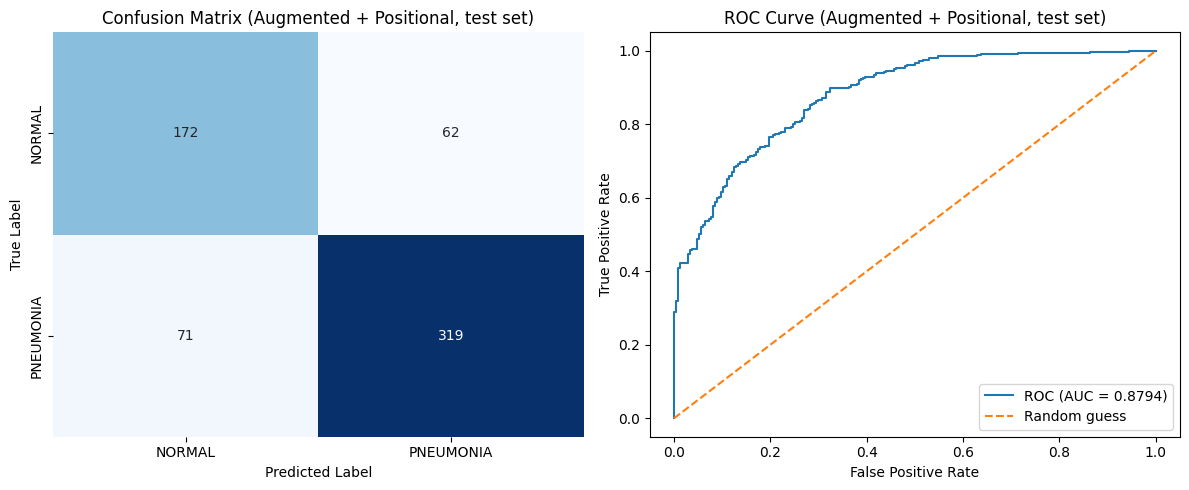

--- (Augmented + Positional, train set) ---
Accuracy: 0.8499
Precision: 0.9479
Recall: 0.8444
Specificity: 0.8658
Cohen Kappa: 0.6438
AUC: 0.9203
False positives (NORMAL -> PNEUMONIA): 180, False negatives: 603

Test-set comparison:


,Accuracy,Precision,Recall,Specificity,Kappa,AUC,FP,FN
Baseline,0.8109,0.8036,0.9231,0.6239,0.5755,0.8723,88.0,30.0
Augmented,0.7981,0.8455,0.8282,0.7479,0.5722,0.8906,59.0,67.0
Aug + Positional,0.7869,0.8373,0.8179,0.7350,0.5488,0.8794,62.0,71.0
Change (Pos vs Aug),-0.0112,-0.0083,-0.0103,-0.0128,-0.0234,-0.0112,3.0,4.0



Train vs test accuracy gap:


,Train accuracy,Test accuracy,Gap
Baseline,0.9080,0.8109,0.0971
Augmented,0.8439,0.7981,0.0459
Aug + Positional,0.8499,0.7869,0.0630


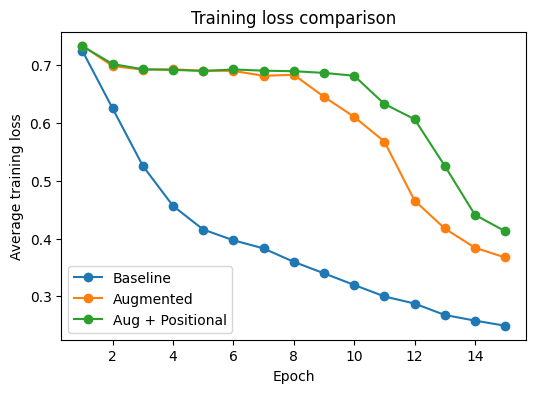

In [29]:
# ============================================================
# Evaluate and compare: Baseline vs Augmented vs Augmented + Positional
# ============================================================
pos_metrics = test_model(model_pos, test_loader, title="(Augmented + Positional, test set)")
pos_train_metrics = test_model(model_pos, train_eval_loader,
                               title="(Augmented + Positional, train set)", plot=False)

comparison_all = pd.DataFrame({
    "Baseline": baseline_metrics,
    "Augmented": aug_metrics,
    "Aug + Positional": pos_metrics,
}).T
comparison_all.loc["Change (Pos vs Aug)"] = (
    comparison_all.loc["Aug + Positional"] - comparison_all.loc["Augmented"]
)
print("\nTest-set comparison:")
display(comparison_all.round(4))

gap_all = pd.DataFrame({
    "Train accuracy": [baseline_train_metrics["Accuracy"], aug_train_metrics["Accuracy"],
                       pos_train_metrics["Accuracy"]],
    "Test accuracy": [baseline_metrics["Accuracy"], aug_metrics["Accuracy"],
                      pos_metrics["Accuracy"]],
}, index=["Baseline", "Augmented", "Aug + Positional"])
gap_all["Gap"] = gap_all["Train accuracy"] - gap_all["Test accuracy"]
print("\nTrain vs test accuracy gap:")
display(gap_all.round(4))

plt.figure(figsize=(6, 4))
plt.plot(range(1, NUM_EPOCHS + 1), loss_list, marker="o", label="Baseline")
plt.plot(range(1, NUM_EPOCHS + 1), loss_list_aug, marker="o", label="Augmented")
plt.plot(range(1, NUM_EPOCHS + 1), loss_list_pos, marker="o", label="Aug + Positional")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("Training loss comparison")
plt.legend()
plt.show()

In [31]:
# ============================================================
# EXPERIMENT 3: augmentation + convolutional stem
# Only change vs the augmented model: the patch-embedding module.
# ============================================================

class ConvStemEmbedding(nn.Module):
    def __init__(self, in_channels=3, embed_dim=384):
        super().__init__()
        channels = [in_channels, 48, 96, 192, 384]
        layers = []
        for c_in, c_out in zip(channels[:-1], channels[1:]):
            layers += [
                nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            ]
        layers.append(nn.Conv2d(channels[-1], embed_dim, kernel_size=1))   # final 1x1 projection
        self.stem = nn.Sequential(*layers)
        self.num_patches = 14 * 14

    def forward(self, x):
        x = self.stem(x)        # [B, 384, 14, 14]
        x = x.flatten(2)        # [B, 384, 196]
        x = x.transpose(1, 2)   # [B, 196, 384]
        return x


class VisionTransformerConvStem(VisionTransformer):
    def __init__(self, image_size, patch_size, in_channels, embed_dim, num_heads,
                 num_layers, num_classes, feedforward_dim=2048, dropout=0.1):
        # Build the same ViT as before (same seed -> same transformer weights as model_aug)
        super().__init__(image_size, patch_size, in_channels, embed_dim, num_heads,
                         num_layers, num_classes, feedforward_dim, dropout)
        # Swap only the patch embedding; forward() is inherited unchanged
        self.patch_embedding = ConvStemEmbedding(in_channels, embed_dim)


set_seed(42)
model_stem = VisionTransformerConvStem(224, 16, 3, 384, 8, 8, 2, 1024).to(device)

# Sanity checks: output shape and size of the change
print("Output shape:", model_stem(torch.randn(2, 3, 224, 224).to(device)).shape)
n_aug = sum(p.numel() for p in model_aug.parameters())
n_stem = sum(p.numel() for p in model_stem.parameters())
print(f"Parameters: augmented = {n_aug:,}, conv stem = {n_stem:,} (+{n_stem - n_aug:,})")

criterion_stem = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 0.4], device=device)).to(device)
optimizer_stem = optim.Adam(model_stem.parameters(), lr=1e-4)
scheduler_stem = optim.lr_scheduler.CosineAnnealingLR(optimizer_stem, T_max=NUM_EPOCHS, eta_min=1e-6)

model_stem, lr_list_stem, loss_list_stem = train_model(
    model_stem, criterion_stem, optimizer_stem, scheduler_stem, train_loader_aug   # same augmented data
)
torch.save(model_stem.state_dict(), "chest_xray_vit_aug_convstem.pth")

Output shape: torch.Size([2, 2])
Parameters: augmented = 11,343,106, conv stem = 12,069,298 (+726,192)


Epoch 1/15: 100%|██████████| 326/326 [00:57<00:00,  5.69it/s, loss=0.341] 


Epoch 1: avg loss = 0.4463, lr = 1.00e-04


Epoch 2/15: 100%|██████████| 326/326 [00:57<00:00,  5.66it/s, loss=0.2]   


Epoch 2: avg loss = 0.3320, lr = 9.89e-05


...

Epoch 13: avg loss = 0.1145, lr = 1.05e-05


Epoch 14/15: 100%|██████████| 326/326 [00:56<00:00,  5.76it/s, loss=0.144]  


Epoch 14: avg loss = 0.0963, lr = 5.28e-06


Epoch 15/15: 100%|██████████| 326/326 [00:56<00:00,  5.74it/s, loss=0.179]  


Epoch 15: avg loss = 0.1028, lr = 2.08e-06
LR per epoch: ['1.00e-04', '9.89e-05', '9.57e-05', '9.05e-05', '8.36e-05', '7.52e-05', '6.58e-05', '5.57e-05', '4.53e-05', '3.52e-05', '2.58e-05', '1.74e-05', '1.05e-05', '5.28e-06', '2.08e-06']


--- (Augmented + Conv stem, test set) ---
Accuracy: 0.8798
Precision: 0.8621
Recall: 0.9615
Specificity: 0.7436
Cohen Kappa: 0.7333
AUC: 0.9542
False positives (NORMAL -> PNEUMONIA): 60, False negatives: 15


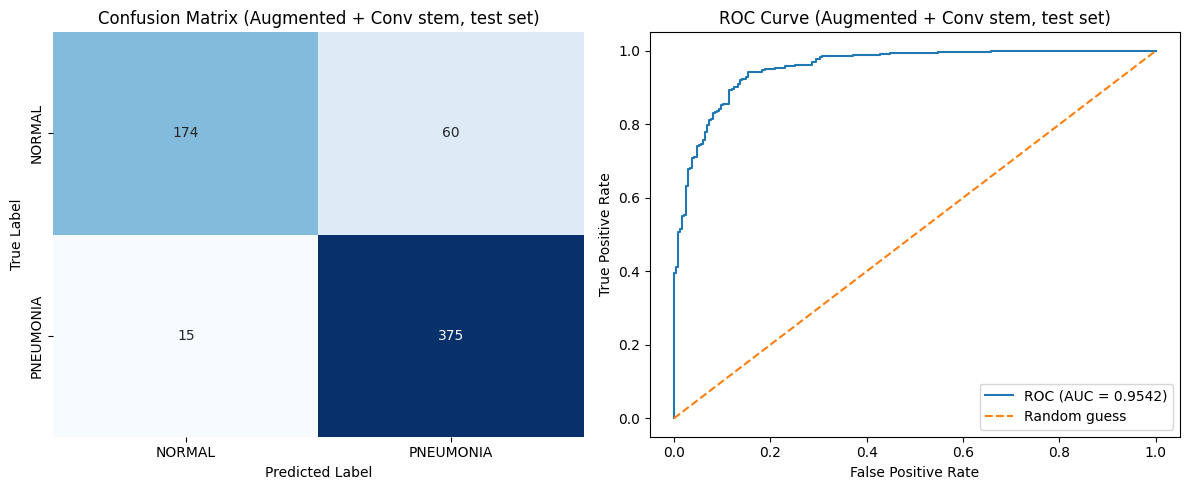

--- (Augmented + Conv stem, train set) ---
Accuracy: 0.9590
Precision: 0.9946
Recall: 0.9499
Specificity: 0.9851
Cohen Kappa: 0.8970
AUC: 0.9951
False positives (NORMAL -> PNEUMONIA): 20, False negatives: 194

Test-set comparison:


,Accuracy,Precision,Recall,Specificity,Kappa,AUC,FP,FN
Baseline,0.8109,0.8036,0.9231,0.6239,0.5755,0.8723,88.0,30.0
Augmented,0.7981,0.8455,0.8282,0.7479,0.5722,0.8906,59.0,67.0
Aug + Positional,0.7869,0.8373,0.8179,0.7350,0.5488,0.8794,62.0,71.0
Aug + Conv stem,0.8798,0.8621,0.9615,0.7436,0.7333,0.9542,60.0,15.0
Change (Conv stem vs Aug),0.0817,0.0165,0.1333,-0.0043,0.1612,0.0636,1.0,-52.0



Train vs test accuracy gap:


,Train accuracy,Test accuracy,Gap
Baseline,0.9080,0.8109,0.0971
Augmented,0.8439,0.7981,0.0459
Aug + Positional,0.8499,0.7869,0.0630
Aug + Conv stem,0.9590,0.8798,0.0792


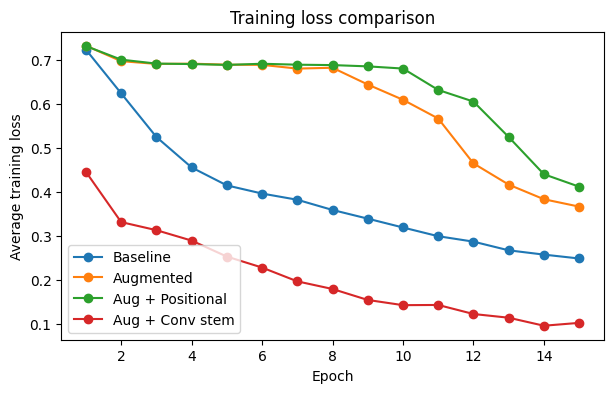

In [32]:
# ============================================================
# Evaluate and compare all models
# ============================================================
stem_metrics = test_model(model_stem, test_loader, title="(Augmented + Conv stem, test set)")
stem_train_metrics = test_model(model_stem, train_eval_loader,
                                title="(Augmented + Conv stem, train set)", plot=False)

comparison_final = pd.DataFrame({
    "Baseline": baseline_metrics,
    "Augmented": aug_metrics,
    "Aug + Positional": pos_metrics,
    "Aug + Conv stem": stem_metrics,
}).T
comparison_final.loc["Change (Conv stem vs Aug)"] = (
    comparison_final.loc["Aug + Conv stem"] - comparison_final.loc["Augmented"]
)
print("\nTest-set comparison:")
display(comparison_final.round(4))

gap_final = pd.DataFrame({
    "Train accuracy": [baseline_train_metrics["Accuracy"], aug_train_metrics["Accuracy"],
                       pos_train_metrics["Accuracy"], stem_train_metrics["Accuracy"]],
    "Test accuracy": [baseline_metrics["Accuracy"], aug_metrics["Accuracy"],
                      pos_metrics["Accuracy"], stem_metrics["Accuracy"]],
}, index=["Baseline", "Augmented", "Aug + Positional", "Aug + Conv stem"])
gap_final["Gap"] = gap_final["Train accuracy"] - gap_final["Test accuracy"]
print("\nTrain vs test accuracy gap:")
display(gap_final.round(4))

plt.figure(figsize=(7, 4))
plt.plot(range(1, NUM_EPOCHS + 1), loss_list, marker="o", label="Baseline")
plt.plot(range(1, NUM_EPOCHS + 1), loss_list_aug, marker="o", label="Augmented")
plt.plot(range(1, NUM_EPOCHS + 1), loss_list_pos, marker="o", label="Aug + Positional")
plt.plot(range(1, NUM_EPOCHS + 1), loss_list_stem, marker="o", label="Aug + Conv stem")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("Training loss comparison")
plt.legend()
plt.show()

## Task 2: Medical Image Abnormality Detection (Chest X-ray Detection)

**Description:**

You are tasked with implementing and training a **Faster R-CNN** model to detect abnormalities in chest X-ray images. The task focuses on learning how to apply object detection methods in medical imaging, from dataset preparation to model evaluation and visualization.

**Requirements:**

1. Build and train a **Faster R-CNN** model with a ResNet-50 backbone using the provided code framework.

2. Use the given chest X-ray dataset with bounding box annotations:
   - **Abnormality**: Consolidation (lung consolidation detection)  
   - **Training set**: 965 images  
   - **Test set**: 125 images  
   - **Annotations**: JSON format with bounding box coordinates and class labels

3. Implement the Faster R-CNN model and finish the training pipeline.

4. Evaluate your model using detection metrics relevant to medical imaging (e.g., **precision, recall, and average recall at fixed FP/image**).

5. Visualize detection results by comparing predicted bounding boxes (with confidence scores) against ground truth annotations.

**Deliverables:**

- Completed code implementing the full training and evaluation pipeline.  
- Quantitative results showing detection performance on the test set.  
- Visualizations of predictions vs. ground truth on sample chest X-ray images.  
- A short report describing the methods and refinements you used to improve performance.

**Assessment for Task 2 (13 points):** Core implementation **7 points**; Optimization research experiment **6 points**.


**Step 0: Required setup**


Environment preparation

In [33]:
!pip install torch torchvision tqdm matplotlib pillow scipy

Data download

Please download the dataset from https://drive.google.com/drive/folders/1HE2sHfnMU8ZUH26d0mIiXblzJrG2ZEpd?usp=drive_link to to implement a detection task over Chest X-ray images.

There are two folders: **train** and **test**, which contain the images for the training and testing datasets, respectively.

There are also two accompanying files:

- train.json: annotations for the training data

- test.json: annotations for the test data

**Step 1:**

**Please implement a custom PyTorch Dataset class for loading chest X-ray images with their corresponding bounding box annotations. Please pay attention to the format required by the Faster R-CNN model (1 point).**

In [35]:
import os

print("Attached inputs:", os.listdir("/kaggle/input"))

# List every .json file and every folder named train/test
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".json"):
            print("JSON:", os.path.join(root, f))
    for d in dirs:
        if d.lower() in ("train", "test"):
            print("Folder:", os.path.join(root, d))

Attached inputs: ['datasets']
Folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
Folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
Folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
Folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
Folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train


In [34]:
import torch
import torchvision.transforms as T
import numpy as np
import os, json

from torch.utils.data import Dataset, DataLoader
from PIL import Image


# In this dataset, we only detect consolidation
CLASSES = ["Consolidation"]
CLS2ID = {c: i + 1 for i, c in enumerate(CLASSES)}


class ChestXDet10(Dataset):
    def __init__(self, base, split="train", transforms=None):
        self.base = base
        self.split = split
        self.transforms = transforms
        self.img_dir = f"{base}/{split}"
        self.ann = self.read_json(f"{base}/{split}.json")

        self.items = []
        for it in self.ann:
            p = self._try_read(os.path.join(self.img_dir, it["file_name"]))
            if p:
                self.items.append((p, it))
        print(f"[{split}] usable images:", len(self.items))

    def read_json(self, path):
        with open(path, "r") as f:
            return json.load(f)

    def _try_read(self, img_path):
        if os.path.exists(img_path):
            return img_path
        alt = img_path.replace(".png", ".PNG")
        return alt if os.path.exists(alt) else None

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        '''
            Expected output:
            img: tensor of shape (3, H, W)
            target: dict of the following keys:
                boxes: tensor of shape (N, 4)  # [x1, y1, x2, y2]
                labels: tensor of shape (N)
            img_path: the path of the image
        '''
        img_path, it = self.items[idx]

        # Load the image as RGB (3 channels)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        syms = it.get("syms", [])
        raw_boxes = it.get("boxes", [])

        # 🔧 Keep only classes we detect (guards against other ChestXDet10 labels)
        pairs = [(s, b) for s, b in zip(syms, raw_boxes) if s in CLS2ID]
        if pairs:
            boxes = np.array([b for _, b in pairs], dtype=np.float32).reshape(-1, 4)
            labels = np.array([CLS2ID[s] for s, _ in pairs], dtype=np.int64)
        else:
            boxes = np.zeros((0, 4), dtype=np.float32)
            labels = np.zeros((0,), dtype=np.int64)

        # Clamp boxes to the image
        if len(boxes):
            boxes[:, 0::2] = np.clip(boxes[:, 0::2], 0, w - 1)
            boxes[:, 1::2] = np.clip(boxes[:, 1::2], 0, h - 1)
            # 🔧 Drop zero-size boxes (Faster R-CNN rejects them)
            valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes, labels = boxes[valid], labels[valid]

        # Convert to tensors: coordinates are float, class labels are int64
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target, os.path.basename(img_path)


def collate_fn(batch):
    imgs, targets, names = list(zip(*batch))
    return list(imgs), list(targets), list(names)


# Find the folder containing train.json / test.json
BASE = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "train.json" in files and "test.json" in files:
        BASE = root
        break
if BASE is None:
    raise FileNotFoundError("Could not find train.json / test.json under /kaggle/input")
print("Data folder:", BASE)

# 🔧 /kaggle/input is read-only, so all outputs go here
OUT_DIR = "/kaggle/working"

train_tfms = T.Compose([T.ToTensor()])
test_tfms = T.Compose([T.ToTensor()])

train_set = ChestXDet10(BASE, "train", transforms=train_tfms)
test_set = ChestXDet10(BASE, "test", transforms=test_tfms)

# Batch size 4 due to the memory limit
train_loader = DataLoader(train_set, batch_size=4, shuffle=True, num_workers=2, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

FileNotFoundError: Could not find train.json / test.json under /kaggle/input

**Step 2:**

**Please set up the Faster R-CNN model architecture with ResNet-50 backbone. This involves defining box head and box predictor (2 points).**

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
from torchvision.ops import MultiScaleRoIAlign
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead, RegionProposalNetwork
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.models.detection.generalized_rcnn import GeneralizedRCNN
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.models.detection._utils import overwrite_eps
from torchvision.models.detection.backbone_utils import (
    _resnet_fpn_extractor,
    _validate_trainable_layers,
)
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.ops import misc as misc_nn_ops
from torch.hub import load_state_dict_from_url


class FasterRCNN(GeneralizedRCNN):
    """
    Implements Faster R-CNN (RPN + RoI heads) on top of a given backbone.
    Training: model(images, targets) returns a dict of losses.
    Inference: model(images) returns a list of dicts with boxes, labels and scores.
    """

    def __init__(
        self,
        backbone,
        num_classes=None,
        # transform parameters
        min_size=800,
        max_size=1333,
        image_mean=None,
        image_std=None,
        # RPN parameters
        rpn_anchor_generator=None,
        rpn_head=None,
        rpn_pre_nms_top_n_train=2000,
        rpn_pre_nms_top_n_test=1000,
        rpn_post_nms_top_n_train=2000,
        rpn_post_nms_top_n_test=1000,
        rpn_nms_thresh=0.7,
        rpn_fg_iou_thresh=0.7,
        rpn_bg_iou_thresh=0.3,
        rpn_batch_size_per_image=256,
        rpn_positive_fraction=0.5,
        rpn_score_thresh=0.0,
        # Box parameters
        box_roi_pool=None,
        box_head=None,
        box_predictor=None,
        box_score_thresh=0.05,
        box_nms_thresh=0.5,
        box_detections_per_img=100,
        box_fg_iou_thresh=0.5,
        box_bg_iou_thresh=0.5,
        box_batch_size_per_image=512,
        box_positive_fraction=0.25,
        bbox_reg_weights=None,
    ):
        if not hasattr(backbone, "out_channels"):
            raise ValueError(
                "backbone should contain an attribute out_channels "
                "specifying the number of output channels (assumed to be the "
                "same for all the levels)"
            )

        assert isinstance(rpn_anchor_generator, (AnchorGenerator, type(None)))
        assert isinstance(box_roi_pool, (MultiScaleRoIAlign, type(None)))

        out_channels = backbone.out_channels

        if rpn_anchor_generator is None:
            anchor_sizes = ((32,), (64,), (128,), (256,), (512,))
            aspect_ratios = ((0.5, 1.0, 2.0),) * len(anchor_sizes)
            rpn_anchor_generator = AnchorGenerator(anchor_sizes, aspect_ratios)
        if rpn_head is None:
            rpn_head = RPNHead(out_channels, rpn_anchor_generator.num_anchors_per_location()[0])

        rpn_pre_nms_top_n = dict(training=rpn_pre_nms_top_n_train, testing=rpn_pre_nms_top_n_test)
        rpn_post_nms_top_n = dict(training=rpn_post_nms_top_n_train, testing=rpn_post_nms_top_n_test)

        rpn = RegionProposalNetwork(
            rpn_anchor_generator,
            rpn_head,
            rpn_fg_iou_thresh,
            rpn_bg_iou_thresh,
            rpn_batch_size_per_image,
            rpn_positive_fraction,
            rpn_pre_nms_top_n,
            rpn_post_nms_top_n,
            rpn_nms_thresh,
            score_thresh=rpn_score_thresh,
        )

        if box_roi_pool is None:
            box_roi_pool = MultiScaleRoIAlign(featmap_names=["0", "1", "2", "3"], output_size=7, sampling_ratio=2)

        if box_head is None:
            resolution = box_roi_pool.output_size[0]
            representation_size = 1024
            box_head = TwoMLPHead(out_channels * resolution ** 2, representation_size)

        if box_predictor is None:
            representation_size = 1024
            box_predictor = FastRCNNPredictor(representation_size, num_classes)

        roi_heads = RoIHeads(
            box_roi_pool,
            box_head,
            box_predictor,
            box_fg_iou_thresh,
            box_bg_iou_thresh,
            box_batch_size_per_image,
            box_positive_fraction,
            bbox_reg_weights,
            box_score_thresh,
            box_nms_thresh,
            box_detections_per_img,
        )

        if image_mean is None:

**Step 3**:

**Please implement the training loop and model optimization. Also please implement the learning rate decay (1 point).**


In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=0.00005, weight_decay=1e-4)
lr_scheduler = # [TODO] implement the learning rate scheduler. Use a scheduler from torch.optim.lr_scheduler.

def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    pbar = tqdm(enumerate(data_loader), total=len(data_loader))

    total_loss = 0.0

    for i, (images, targets, _) in pbar:

        # [TODO] implement the training loop

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = # todo1: get the loss_dict use model and input data
        losses = sum(loss for loss in loss_dict.values())
        loss_value = losses.item()

        # todo2: zero grad the optimizer
        # finish todo2 here

        # todo3: backward to compute the gradient
        # finish todo3 here

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # todo4: optimize the param in the model
        # finish todo4 here

        total_loss += loss_value



        pbar.set_postfix(loss=loss_value)
    avg_loss = total_loss / len(data_loader)
    return avg_loss


EPOCHS = 5  # Here we only train for 5 epochs
for epoch in range(EPOCHS):
    avg_loss = train_one_epoch(model, optimizer, train_loader, device)
    print(f"Epoch {epoch} loss: {avg_loss}")
    lr_scheduler.step()

# save the model
WEIGHTS = f"{BASE}/fasterrcnn_chestxdet10.pth"
torch.save(model.state_dict(), WEIGHTS)
print("saved to:", WEIGHTS)

**Step 4: (1 point)**

After training, please use the trained model to generate predictions on the test set. In this step, you should:
1. Model Inference: Run trained model on test images

2. Confidence Filtering: Apply score threshold to filter low-confidence predictions

3. Output Formatting: Convert predictions to evaluation format

4. File Management: Save predictions as JSON files and save the predictions in the pred_json folder


**Output Format:**

Each prediction file should be named as the original image name with .json extension.
Each prediction file contains:
- Class Name: "Consolidation" for detected regions

- Coordinates: [x1, y1, x2, y2] bounding box coordinates

- Confidence: Detection confidence score

[{"Class Name": [x1, y1, x2, y2, confidence]}]

Example:

[{"Consolidation": [570.3914184570312, 419.7106018066406, 709.7536010742188, 596.7514038085938, 0.27996760606765747]}]

[{"Consolidation": [235.6313934326172, 356.14544677734375, 435.51422119140625, 753.4442138671875, 0.8444843888282776]}, {"Consolidation": [598.0247192382812, 368.6965637207031, 798.2308959960938, 758.9693603515625, 0.4207973778247833]}]

In [ ]:
import torch
import json, os
from tqdm import tqdm

model.eval()
pred_dir = f"{BASE}/pred_json"
os.makedirs(pred_dir, exist_ok=True)

score_thresh = 0.02

with torch.no_grad():
    for images, targets, names in tqdm(test_loader):
        # [TODO] implement the model inference and generate the prediction
        images_gpu = # todo1: put the variable in images to gpu
        outputs = # todo2: do inference to get the prediction of the images

        for name, out, im in zip(names, outputs, images):
            boxes = out["boxes"].cpu().numpy()
            scores = out["scores"].cpu().numpy()
            labels = out["labels"].cpu().numpy()

            per_image = []
            for (x1,y1,x2,y2), sc, lb in zip(boxes, scores, labels):
                if sc < score_thresh:
                    continue
                # label==0 background；TorchVision's label>=1 corresponds to our 0..9 classes
                if lb == 0:
                    continue
                cls_name = CLASSES[lb-1]
                per_image.append({cls_name: [float(x1), float(y1), float(x2), float(y2), float(sc)]})

            out_path = os.path.join(pred_dir, os.path.splitext(name)[0] + ".json")
            with open(out_path, "w") as f:
                json.dump(per_image, f)




len(os.listdir(pred_dir))

**Step 5:**

**Now you need to implement the compuation of IOU to get the evaluation of your prediction (1 point).**


In [ ]:
import numpy as np
import json
import os

from scipy import interpolate



def IOU(box1, gts):
    # compute overlaps
    # intersection

    # compute the intersection over union

    # The bounding box coordinates are defined as closed intervals,
    # i.e., both the top-left (x1, y1) and bottom-right (x2, y2) points are inclusive, so the width is (x2 - x1 + 1) and the height is (y2 - y1 + 1).
    ixmin = np.maximum(gts[:, 0], box1[0])
    iymin = np.maximum(gts[:, 1], box1[1])
    ixmax = np.minimum(gts[:, 2], box1[2])
    iymax = np.minimum(gts[:, 3], box1[3])

    # [TODO] compute the intersection width (iw) and intersection height (ih)
    iw = # todo1
    ih = # todo2

    inters = iw * ih

    # union
    uni = ((box1[2] - box1[0] + 1.) * (box1[3] - box1[1] + 1.) +
           (gts[:, 2] - gts[:, 0] + 1.) *
           (gts[:, 3] - gts[:, 1] + 1.) - inters)

    overlaps = inters / uni


    return overlaps

def FROC(boxes_all, gts_all, iou_th):
    # Compute the FROC curve, for single class only
    nImg = len(boxes_all)
    img_idxs_ori = np.hstack([[i]*len(boxes_all[i]) for i in range(nImg)]).astype(int)
    boxes_cat = np.vstack(boxes_all)
    scores = boxes_cat[:, -1]
    ord = np.argsort(scores)[::-1]
    boxes_cat = boxes_cat[ord, :4]
    img_idxs = img_idxs_ori[ord]

    hits = [np.zeros((len(gts),), dtype=bool) for gts in gts_all]
    nHits = 0
    nMiss = 0
    tps = []
    fps = []
    precisions = []

    for i in range(len(boxes_cat)):
        overlaps = IOU(boxes_cat[i, :], gts_all[img_idxs[i]])
        if overlaps.shape[0] == 0:
            nMiss += 1
        elif overlaps.max() < iou_th:
            nMiss += 1
        else:
            max_index = np.argmax(overlaps)
            if overlaps[max_index] >= iou_th and not hits[img_idxs[i]][max_index]:
                hits[img_idxs[i]][max_index] = True
                nHits += 1
            elif overlaps[max_index] >= iou_th and hits[img_idxs[i]][max_index]:
                nMiss += 1

        tps.append(nHits)
        fps.append(nMiss)
        if nHits + nMiss > 0:
            precisions.append(nHits / (nHits + nMiss))
        else:
            precisions.append(0.0)

    nGt = len(np.vstack(gts_all))
    sens = np.array(tps, dtype=float) / nGt
    fp_per_img = np.array(fps, dtype=float) / nImg
    precisions = np.array(precisions, dtype=float)

    if len(tps) != 0:
        tp_gt = [tps[-1], nGt]
    else:
        tp_gt = None

    return tp_gt, sens, fp_per_img, precisions


def eval_FROC(gt_boxes, all_boxes, CLASSES, avgFP=[0.05, 0.1, 0.2, 0.5], iou_th=0.5):
    mean_recall = [0.0 for _ in range(len(avgFP) + 1)]
    mean_precision = [0.0 for _ in range(len(avgFP) + 1)]

    for cls in range(len(all_boxes)):
        tp_gt, sens, fp_per_img, precisions = FROC(all_boxes[cls], gt_boxes[cls], iou_th)

        # interpolate precision and recall
        if len(fp_per_img) > 1:
            f_recall = interpolate.interp1d(fp_per_img, sens, fill_value="extrapolate")
            f_precision = interpolate.interp1d(fp_per_img, precisions, fill_value="extrapolate")
        else:
            continue

        for idx, fp in enumerate(avgFP):
            if fp <= fp_per_img[-1]:
                mean_recall[idx] += float(f_recall(fp))
                mean_precision[idx] += float(f_precision(fp))

    print('='*20, 'Recall & Precision', '='*20)
    for i, fp in enumerate(avgFP):
        print('Recall@%.2f=%.2f%%, Precision@%.2f=%.2f%%' %
              (fp, mean_recall[i]/len(CLASSES)*100.0,
               fp, mean_precision[i]/len(CLASSES)*100.0))


def sens_at_FP(boxes_all, gts_all, avgFP, iou_th):
    # compute the sensitivity at avgFP (average FP per image)
    tp_gt, sens, fp_per_img = FROC(boxes_all, gts_all, iou_th)

    # gt = tp and no fp
    if len(fp_per_img)!= 0 and sens[-1] == 1 and fp_per_img[-1] == 0:
        res = np.ones(1)
        valid_avgFP = np.zeros(1)

        return res, valid_avgFP

    if len(fp_per_img) != 0:
        max_fp = fp_per_img[-1]

        # tp = 0 and fp = 1
        if len(fp_per_img) == 1:
            fp_per_img = np.insert(fp_per_img, 0, 0.0)
            sens = np.insert(sens, 0, 0.0)

        if max_fp != 0:
            f = interpolate.interp1d(fp_per_img, sens, fill_value='extrapolate')
        if(avgFP[-1] < max_fp):
            valid_avgFP_end_idx = len(avgFP)
        else:
            valid_avgFP_end_idx = np.argwhere(np.array(avgFP) >= max_fp)[0][0]
        valid_avgFP = np.hstack((avgFP[:valid_avgFP_end_idx], max_fp))
        if max_fp != 0:
            res = f(valid_avgFP)
        # no fp and tp < gt
        elif max_fp == 0 and tp_gt:
            res = np.zeros(len(valid_avgFP))
            res[:] = 1.0*tp_gt[0] / tp_gt[1]
    # no tp
    else:
        res = np.zeros(1)
        valid_avgFP = np.zeros(1)

    return res, valid_avgFP


def get_pred_info(pred_dir, file_id_list, CLASSES):
    class_num = len(CLASSES)
    all_boxes = [[] for _ in range(class_num)]

    for cls_idx, class_name in enumerate(CLASSES):
        for file_id in file_id_list[cls_idx]:
            file_id = file_id.replace('.png', '.json')
            json_file = os.path.join(pred_dir, file_id)
            all_box = []
            if os.path.exists(json_file) and os.stat(json_file).st_size > 0:
                annos = json.load(open(json_file))
                for i in range(len(annos)):
                    if class_name in annos[i].keys():
                        all_box.append(annos[i][class_name])
                    elif class_name.lower() in annos[i].keys():
                        all_box.append(annos[i][class_name.lower()])
            if all_box:
                all_box = np.array(all_box, dtype=np.float32)
            else:
                all_box = np.zeros((0, 5), dtype=np.float32)
            all_boxes[cls_idx].append(all_box)

    return all_boxes

def get_gt_info(test_json, CLASSES):
    class_num = len(CLASSES)
    gt_boxes = [[] for _ in range(class_num)]
    file_id_list = [[] for _ in range(class_num)]

    annos = json.load(open(test_json))
    for cls_idx, class_name in enumerate(CLASSES):
        for entry in annos:
            syms, boxes = entry['syms'], entry['boxes']
            file_name = entry['file_name']
            gt_box = []
            for idx, (sym, box) in enumerate(zip(syms, boxes)):
                if sym == class_name:
                    gt_box.append(box)
            if gt_box:
                gt_box = np.array(gt_box, dtype=np.float32)
            else:
                gt_box = np.zeros((0, 4), dtype=np.float32)
            gt_boxes[cls_idx].append(gt_box)
            file_id_list[cls_idx].append(file_name)

    return gt_boxes, file_id_list


test_json = BASE + "/test.json"
pred_dir = BASE + "/pred_json"

gt_boxes, file_id_list = get_gt_info(test_json, CLASSES)
all_boxes = get_pred_info(pred_dir, file_id_list, CLASSES)
eval_FROC(gt_boxes, all_boxes, CLASSES)


**Step 6**:

**Please create visual comparisons between model predictions and ground truth annotations.** This helps understand the model's performance qualitatively and identify areas for improvement. **(1 point)**

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import ImageDraw

def draw_boxes_pil(img, boxes, labels, classes, scores=None,
                   color="red", text_color="white"):
    # function to draw the boxes on the image

    img = img.copy()
    draw = ImageDraw.Draw(img)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [int(v) for v in box]
        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)

        if len(labels) > 0:
            lb = int(labels[i])
            if 1 <= lb <= len(classes):
                name = classes[lb - 1]
            else:
                name = f"cls{lb}"
        else:
            name = ""

        if scores is not None:
            txt = f"{name}:{float(scores[i]):.2f}"
        else:
            txt = name if name else "GT"

        tw = len(txt) * 6
        th = 12
        draw.rectangle([x1, max(0, y1 - th), x1 + tw + 4, y1], fill=color)
        draw.text((x1+2, y1 - th), txt, fill=text_color)

    return img

@torch.no_grad()
def viz_pred_gt_fixed(model, dataset, classes, filenames, score_thresh=0.3, device=None):
    """
    This method will visualize the predictions and ground truth for the given filenames in the dataset.
    You should plot 4 images in a 2x4 grid. The top row will be the predictions and the bottom row will be the ground truth.
    Args:
        model: the model to be visualized
        dataset: the custom dataset class
        classes: the classes to be visualized
        filenames: the filenames to be visualized
        score_thresh: the threshold for the confidence score
        device: the device to be used
    Returns:
        None
    """

    model.eval()
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    cols = len(filenames)
    fig, axes = plt.subplots(2, cols, figsize=(4*cols, 8))
    if cols == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    # Find the index of the given filenames in the dataset
    name2idx = {os.path.basename(it["file_name"]): i for i, (_,it) in enumerate(dataset.items)} \
               if hasattr(dataset, "items") else {dataset[i][2]: i for i in range(len(dataset))}

    for ci, fname in enumerate(filenames):
        idx = name2idx[fname]
        img_tensor, target, basename = dataset[idx]
        img_pil = T.ToPILImage()(img_tensor)

        # Model inference
        inp = img_tensor.to(device)
        out = model([inp])[0]

        boxes_p = out["boxes"].cpu().numpy()
        scores_p = out["scores"].cpu().numpy()
        labels_p = out["labels"].cpu().numpy()
        keep = scores_p >= score_thresh
        boxes_p, scores_p, labels_p = boxes_p[keep], scores_p[keep], labels_p[keep]

        # GT
        boxes_g = target["boxes"].numpy()
        labels_g = target["labels"].numpy()

        # [TODO] Use draw_boxes_pil function to draw the predictions and ground truth
        # requirement:
        #   pred_vis should be red
        #   gt_vis should be green
        pred_vis = # todo1
        gt_vis   = # todo2

        axes[0, ci].imshow(pred_vis); axes[0, ci].set_title(f"Pred: {basename}")
        axes[0, ci].axis("off")
        axes[1, ci].imshow(gt_vis);   axes[1, ci].set_title("Ground Truth")
        axes[1, ci].axis("off")

    plt.tight_layout()
    plt.show()




# Visualize the predictions and ground truth for the first 4 images in the test set
filenames = ["40424.png", "41225.png", "62137.png", "45701.png"]

viz_pred_gt_fixed(model, test_set, CLASSES, filenames, score_thresh=0.3, device=device)



**Step 7: Optimization Research Experiment (6 points)**

Using the final Faster R-CNN from Steps 1–6 as the baseline, with its selected hyperparameters fixed, identify **one meaningful improvement opportunity**, analyze its possible cause, and design an experiment to address it.

**Important:** Use the best hyperparameter settings obtained from Steps 1–6 and keep them fixed throughout this experiment. Hyperparameter tuning itself should not be considered an intervention.

1. **Baseline diagnosis (1 point)**: Identify a specific issue in the baseline results and propose a possible cause.

2. **Experiment design (1 point)**: Propose one intervention based on the cause. Change **one** main factor at a time while keeping the other important settings controlled.

3. **Experiment (2 points)**: Implement the proposed experiment in code, run all the experiment including evaluation, and also save all required outputs and results in the notebook.

4. **Analysis and Interpretation (2 points)**: Compare the modified model with the baseline using relevant evaluation metrics, and determine whether the intervention copes with the identified issue

**Possible interventions** include, but are **not limited to**, modifying the detection loss function, hard-negative handling (e.g., foreground-background sampling), anchor design, data augmentation, or model architecture improvement. These are provided only as examples; other interventions are also acceptable.

**Yours:**
1. **Baseline diagnosis**:

2. **Experiment design**:

3. **Experiment**:

In [ ]:
# TODO: Implement and run your experiment here.
# You may add additional code cells if needed.

4. **Analysis and Interpretation**: